## Holiday Package Prediciton

### 1) Problem statement.
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base.
One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information.
The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being.
However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.
### 2) Data Collection.
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction
The data consists of 20 column and 4888 rows.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [32]:
df = pd.read_csv("Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [33]:
df.columns


Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

In [34]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [35]:
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [36]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [37]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [38]:
df['Gender']=df['Gender'].replace('Fe Male','Female')
df['MaritalStatus'] =df['MaritalStatus'].replace('Single','Unmarried')

In [39]:
features_with_na = [features for features in df.columns if df[features].isnull().sum()>1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5),"% missing values")

Age 4.62357 % missing values
TypeofContact 0.51146 % missing values
DurationOfPitch 5.13502 % missing values
NumberOfFollowups 0.92062 % missing values
PreferredPropertyStar 0.53191 % missing values
NumberOfTrips 2.86416 % missing values
NumberOfChildrenVisiting 1.35025 % missing values
MonthlyIncome 4.76678 % missing values


In [40]:
df[features_with_na].select_dtypes(exclude=['object']).describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [41]:
df.Age.fillna(df.Age.median(),inplace = True)

df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace = True)

df.DurationOfPitch.fillna(df.DurationOfPitch.median(),inplace = True)
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0],inplace = True)


df.NumberOfTrips.fillna(df.NumberOfTrips.median(),inplace = True)

df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.median(),inplace = True)
df.MonthlyIncome.fillna(df.MonthlyIncome.median(),inplace = True)
df.NumberOfFollowups.fillna(df.NumberOfFollowups.median(),inplace = True)

In [42]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [43]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [44]:
df.drop('CustomerID',axis = 1 , inplace = True)

### Feature Engg

In [45]:
df['TotalVisiting'] = df['NumberOfChildrenVisiting'] + df['NumberOfFollowups']
df.drop(['NumberOfChildrenVisiting','NumberOfFollowups'], axis = 1 , inplace = True)  

In [46]:
num_features = [feature for feature in df.columns if df[feature].dtype !='0']
print('Number of numerical features:',len(num_features))

Number of numerical features: 18


In [47]:
cat_features = [feature for feature in df.columns if df[feature].dtype =='0']
print('Number of categorical features:',len(cat_features))

Number of categorical features: 0


In [48]:
discrete_features = [feature for feature in num_features if len(df[feature].unique())<25]
print('Discrete features:',len(discrete_features))

Discrete features: 15


In [49]:
continuous_features = [feature for feature in num_features if feature not in discrete_features]  
print('Continuous features:',len(continuous_features))

Continuous features: 3


In [50]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,6.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,4.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,4.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,3.0


In [51]:
from sklearn.model_selection import train_test_split
X = df.drop(['ProdTaken'],axis = 1)
y = df['ProdTaken']

In [52]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [53]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,3,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,6.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,4.0
3,33.0,Company Invited,1,9.0,Salaried,Female,2,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,4.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,2,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,3.0


In [54]:
X_train ,  X_test ,y_train, y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42)

In [55]:
X_train.shape,X_test.shape

((3910, 17), (978, 17))

In [56]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4888 non-null   float64
 1   TypeofContact           4888 non-null   object 
 2   CityTier                4888 non-null   int64  
 3   DurationOfPitch         4888 non-null   float64
 4   Occupation              4888 non-null   object 
 5   Gender                  4888 non-null   object 
 6   NumberOfPersonVisiting  4888 non-null   int64  
 7   ProductPitched          4888 non-null   object 
 8   PreferredPropertyStar   4888 non-null   float64
 9   MaritalStatus           4888 non-null   object 
 10  NumberOfTrips           4888 non-null   float64
 11  Passport                4888 non-null   int64  
 12  PitchSatisfactionScore  4888 non-null   int64  
 13  OwnCar                  4888 non-null   int64  
 14  Designation             4888 non-null   

In [57]:
cat_features = X.select_dtypes(include = "object").columns
num_features = X.select_dtypes(exclude = "object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop = 'first')


preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)

In [58]:
preprocessor

ColumnTransformer(transformers=[('OneHotEncoder', OneHotEncoder(drop='first'),
                                 Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')),
                                ('StandardScaler', StandardScaler(),
                                 Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
      dtype='object'))])

In [59]:
X_train = preprocessor.fit_transform(X_train)

In [60]:
X_test = preprocessor.transform(X_test)

### MOdel Training : RFS

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score

In [70]:
models ={
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train)
    
    y_train_pred= model.predict(X_train)
    y_test_pred= model.predict(X_test)
    
    model_train_acc = accuracy_score(y_train,y_train_pred)
    model_train_f1 = f1_score(y_train,y_train_pred)
    model_train_precision = precision_score(y_train,y_train_pred)
    model_train_recall = recall_score(y_train,y_train_pred)
    model_train_roc_auc = roc_auc_score(y_train,y_train_pred)
    
    
    model_test_acc = accuracy_score(y_test,y_test_pred)
    model_test_f1 = f1_score(y_test,y_test_pred)
    model_test_precision = precision_score(y_test,y_test_pred)
    model_test_recall = recall_score(y_test,y_test_pred)
    model_test_roc_auc = roc_auc_score(y_test,y_test_pred)
    
    
    print(list(models.keys())[i])
    print('='*35)
   
    
    print("Model performance on training data")
    print("accuracy_score: ",model_train_acc)
    print("f1_score: ",model_train_f1)
    print("precision_score: ",model_train_precision)
    print("recall_score: ",model_train_recall)
    print("roc_auc_score: ",model_train_roc_auc)
    print('='*35)

    
    print("Model performance on testing data")
    print("accuracy_score: ",model_test_acc)    
    print("f1_score: ",model_test_f1)
    print("precision_score: ",model_test_precision)
    print("recall_score: ",model_test_recall)
    print("roc_auc_score: ",model_test_roc_auc)
    
    
    print('='*35)
    print('\n')

Random Forest
Model performance on training data
accuracy_score:  1.0
f1_score:  1.0
precision_score:  1.0
recall_score:  1.0
roc_auc_score:  1.0
Model performance on testing data
accuracy_score:  0.9233128834355828
f1_score:  0.7619047619047619
precision_score:  0.967741935483871
recall_score:  0.6282722513089005
roc_auc_score:  0.8115948295934591


Decision Tree
Model performance on training data
accuracy_score:  1.0
f1_score:  1.0
precision_score:  1.0
recall_score:  1.0
roc_auc_score:  1.0
Model performance on testing data
accuracy_score:  0.9079754601226994
f1_score:  0.7643979057591623
precision_score:  0.7643979057591623
recall_score:  0.7643979057591623
roc_auc_score:  0.8536093721934312


Logistic Regression
Model performance on training data
accuracy_score:  0.8447570332480818
f1_score:  0.4101068999028183
precision_score:  0.7033333333333334
recall_score:  0.289437585733882
roc_auc_score:  0.6307294813296886
Model performance on testing data
accuracy_score:  0.84253578732106

In [83]:
rfs_params = {
    "max_depth": [3, 5, 10, 15, 20,None],
    "max_features": [5,7,9,"auto",8],
    "min_samples_split" : [2,8,15,20,10],
    "n_estimators" : [100,200,300,400,500,1000]
}

In [84]:
randomcv_model = [
    ("RF",RandomForestClassifier(),rfs_params)
]

In [85]:
from sklearn.model_selection import RandomizedSearchCV
model_params ={}

for name,model,params in randomcv_model:
   random = RandomizedSearchCV(estimator = model,param_distributions = params,cv = 3,n_iter = 5,scoring = 'accuracy',n_jobs = -1,verbose = 2,random_state = 42)
   random.fit(X_train,y_train)
   model_params[name]=random.best_params_
   
   for model_name in model_params:
       print(f"Best parameters for {model_name}: {model_params[model_name]}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters for RF: {'n_estimators': 400, 'min_samples_split': 15, 'max_features': 8, 'max_depth': 10}


In [89]:
mod={
    "Random Forest": RandomForestClassifier(max_depth=20, max_features=7, min_samples_split=2, n_estimators=1000)
}


for i in range(len(list(mod))):
    model = list(mod.values())[i]
    model.fit(X_train,y_train)
    
    y_train_pred= model.predict(X_train)
    y_test_pred= model.predict(X_test)
    
    model_train_acc = accuracy_score(y_train,y_train_pred)
    model_train_f1 = f1_score(y_train,y_train_pred)
    model_train_precision = precision_score(y_train,y_train_pred)
    model_train_recall = recall_score(y_train,y_train_pred)
    model_train_roc_auc = roc_auc_score(y_train,y_train_pred)
    
    
    model_test_acc = accuracy_score(y_test,y_test_pred)
    model_test_f1 = f1_score(y_test,y_test_pred)
    model_test_precision = precision_score(y_test,y_test_pred)
    model_test_recall = recall_score(y_test,y_test_pred)
    model_test_roc_auc = roc_auc_score(y_test,y_test_pred)
    
    
    print(list(models.keys())[i])
    print('='*35)
   
    
    print("Model performance on training data")
    print("accuracy_score: ",model_train_acc)
    print("f1_score: ",model_train_f1)
    print("precision_score: ",model_train_precision)
    print("recall_score: ",model_train_recall)
    print("roc_auc_score: ",model_train_roc_auc)
    print('='*35)

    
    print("Model performance on testing data")
    print("accuracy_score: ",model_test_acc)    
    print("f1_score: ",model_test_f1)
    print("precision_score: ",model_test_precision)
    print("recall_score: ",model_test_recall)
    print("roc_auc_score: ",model_test_roc_auc)
    
    
    print('='*35)
    print('\n')
    

Random Forest
Model performance on training data
accuracy_score:  1.0
f1_score:  1.0
precision_score:  1.0
recall_score:  1.0
roc_auc_score:  1.0
Model performance on testing data
accuracy_score:  0.9304703476482618
f1_score:  0.7901234567901234
precision_score:  0.9624060150375939
recall_score:  0.6701570680628273
roc_auc_score:  0.8319019139551748




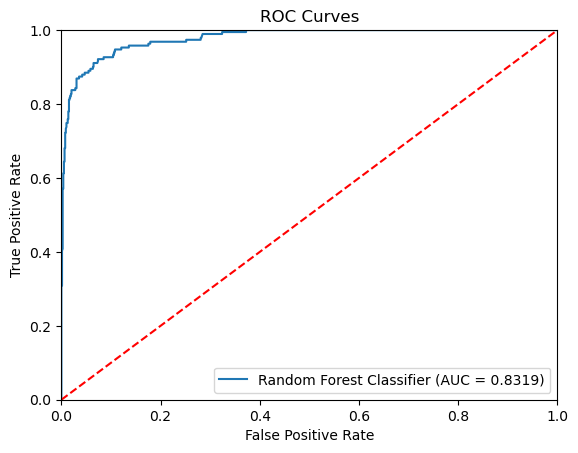

In [96]:

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure()

auc_models = [
    {
        'label': "Random Forest Classifier",
        'model': RandomForestClassifier(max_depth=20, max_features=7, min_samples_split=2, n_estimators=1000),
        'auc': 0.8319019139551748
    }
]

for algo in auc_models:
    model = algo['model']
    model.fit(X_train, y_train)

    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{algo['label']} (AUC = {algo['auc']:.4f})")
    
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()

In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix


def evaluate_model(model, X_test, y_test):
    """Evaluate a trained classifier on test data and print key metrics."""
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 score:", f1_score(y_test, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        print("ROC AUC:", roc_auc_score(y_test, y_proba))

    print("\nClassification report:\n", classification_report(y_test, y_pred))


# Example usage for the last trained model in the notebook:
evaluate_model(model, X_test, y_test)


Accuracy: 0.9284253578732107
Precision: 0.9618320610687023
Recall: 0.6596858638743456
F1 score: 0.782608695652174
Confusion matrix:
 [[782   5]
 [ 65 126]]
ROC AUC: 0.9777037859989223

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96       787
           1       0.96      0.66      0.78       191

    accuracy                           0.93       978
   macro avg       0.94      0.83      0.87       978
weighted avg       0.93      0.93      0.92       978



In [102]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,6.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,4.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,4.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,3.0


In [101]:
def predict_random_input(model, preprocessor, feature_names, input_values):
    """Predict package purchase for one new example given feature values."""
    # input_values should be a dict with keys equal to X.columns
    row = pd.DataFrame([input_values], columns=feature_names)
    X_new = preprocessor.transform(row)
    prediction = model.predict(X_new)[0]

    print("Input values:")
    print(row.T)
    print("\nPredicted class:", prediction)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_new)[0, 1]
        print("Predicted probability of purchase:", proba)
        return prediction, proba

    return prediction


def predict_from_user_input(model, preprocessor, feature_names, input_values):
    """Predict using values supplied by the user in a dict keyed by feature names."""
    missing = [feature for feature in feature_names if feature not in input_values]
    if missing:
        raise ValueError(f"Missing feature values for: {', '.join(missing)}")

    row = pd.DataFrame([input_values], columns=feature_names)

    # Convert numeric columns back to numeric types before transformation
    numeric_cols = df.select_dtypes(exclude="object").columns
    for col in numeric_cols:
        if col in row.columns:
            row[col] = pd.to_numeric(row[col], errors="raise")

    X_new = preprocessor.transform(row)
    prediction = model.predict(X_new)[0]
    result = {"prediction": int(prediction)}

    if hasattr(model, "predict_proba"):
        result["probability"] = float(model.predict_proba(X_new)[0, 1])

    print("Input values:")
    print(row.T)
    print("\nPredicted class:", result["prediction"])
    if "probability" in result:
        print("Predicted probability of purchase:", result["probability"])

    return result


def sample_random_values(X, seed=None):
    """Return a random example from the original training data format."""
    return X.sample(n=1, random_state=seed).iloc[0].to_dict()


# Example usage with a random sample from the original data:
input_example = sample_random_values(X)
predict_random_input(model, preprocessor, X.columns, input_example)

# Example user input dictionary:
# user_input = {
#     "Age": 35,
#     "TypeofContact": "Self Enquiry",
#     "CityTier": 2,
#     "DurationOfPitch": 120,
#     "Occupation": "Salaried",
#     "Gender": "Male",
#     "NumberOfPersonVisiting": 2,
#     "NumberOfFollowups": 1,
#     "ProductPitched": "Food & Beverage",
#     "PreferredPropertyStar": 4,
#     "MaritalStatus": "Married",
#     "NumberOfTrips": 3,
#     "Passport": "Yes",
#     "PitchSatisfactionScore": 5,
#     "OwnCar": "Yes",
#     "NumberOfChildrenVisiting": 0,
#     "MonthlyIncome": 50000,
#     "TotalVisiting": 1,
#     "ProdTaken": 0
# }
# predict_from_user_input(model, preprocessor, X.columns, user_input)


Input values:
                                      0
Age                                36.0
TypeofContact           Company Invited
CityTier                              1
DurationOfPitch                    11.0
Occupation               Large Business
Gender                             Male
NumberOfPersonVisiting                2
ProductPitched                    Basic
PreferredPropertyStar               3.0
MaritalStatus                 Unmarried
NumberOfTrips                       1.0
Passport                              0
PitchSatisfactionScore                5
OwnCar                                1
Designation                   Executive
MonthlyIncome                   18500.0
TotalVisiting                       1.0

Predicted class: 0
Predicted probability of purchase: 0.0990625


(0, 0.0990625)